In [1]:
import pandas as pd
df = pd.read_csv("residential_input.csv")

df

,postcode,households,electricity_per_household_kwh
0,"1,098",2070,1800


In [2]:
households_real = df.loc[0,"households"]
electricity_per_household = df.loc[0,"electricity_per_household_kwh"]

print("Households:", households_real)
print("Electricity per household:", electricity_per_household)

Households: 2070
Electricity per household: 1800


In [3]:
households_simulated = 50

weight = households_real / households_simulated

print("Scaling factor:", weight)

Scaling factor: 41.4


In [4]:
from ramp import User, UseCase
import numpy as np

In [5]:
households = User("households", households_simulated)
washing_users = int(0.3 * households_simulated)

washing_group = User("washing_users", washing_users)

In [6]:
# =========================
# APPLIANCES (IMPROVED)
# =========================

# Fridge (always on)
households.add_appliance(
    name='Fridge',
    number=1,
    power=120,
    func_time=1440,
    window_1=[0,1440]
)

# Lighting (morning + evening)
households.add_appliance(
    name='Lighting',
    number=5,
    power=10,
    func_time=120,
    window_1=[360,540],
    window_2=[1080,1380]
)

# Electronics (spread usage)
households.add_appliance(
    name='Electronics',
    number=2,
    power=70,
    func_time=180,
    window_1=[500,900],
    window_2=[1080,1320]
)

# Cooking (LESS synchronized → wider window)
households.add_appliance(
    name='Cooking',
    number=1,
    power=800,
    func_time=60,
    window_1=[1020,1380]
)

# Washing machine (NOT daily)
washing_group.add_appliance(
    name='WashingMachine',
    number=1,
    power=500,
    func_time=60,
    window_1=[600,1200]
)

# Base load
households.add_appliance(
    name='BaseLoad',
    number=1,
    power=150,
    func_time=1440,
    window_1=[0,1440]
)

    user_name  num_users      name  number  power
0  households         50  BaseLoad       1  150.0

In [7]:
case = UseCase(users=[households, washing_group])

In [8]:
case.initialize(num_days=366)

You will simulate 366 day(s) from 2026-03-17 00:00:00 until 2027-03-18 00:00:00


In [9]:
profiles = case.generate_daily_load_profiles(
    flat=True,
    verbose=False
)

In [10]:
profile = np.array(profiles)

profile_real = profile * weight
profile_kw = profile_real / 1000

In [11]:
annual_energy = profile_kw.sum()/60
daily_energy = annual_energy / 365

print("Peak load (kW):", profile_kw.max())
print("Annual energy (kWh):", annual_energy)
print("Average daily energy (kWh):", daily_energy)

Peak load (kW): 1388.1462642000004
Annual energy (kWh): 5846510.821824004
Average daily energy (kWh): 16017.837868010969


In [12]:
output = pd.DataFrame({
    "minute": np.arange(len(profile_kw)),
    "load_kw": profile_kw
})

output.to_csv("PC1098_residential_load_year.csv", index=False)

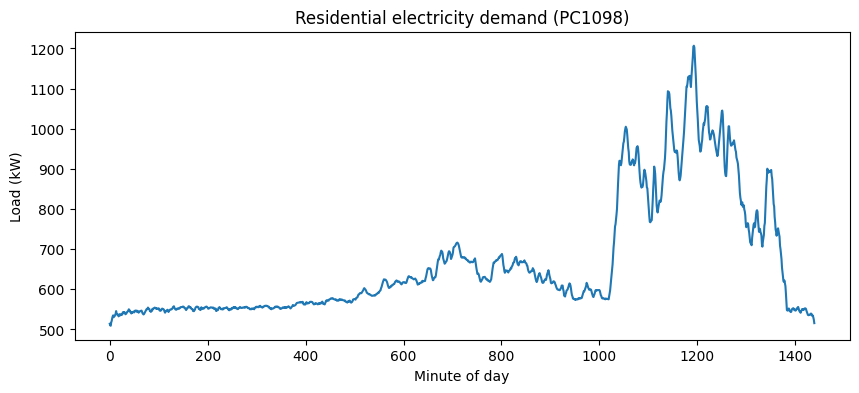

In [13]:
import matplotlib.pyplot as plt
profile_kw = pd.Series(profile_kw).rolling(5, min_periods=1).mean()
plt.figure(figsize=(10,4))
plt.plot(profile_kw[:1440])
plt.xlabel("Minute of day")
plt.ylabel("Load (kW)")
plt.title("Residential electricity demand (PC1098)")
plt.show()

In [14]:
!conda env export > environment.yml